In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate
from helper import *
import seaborn as sns
import pandas as pd
from scipy.spatial.transform import Rotation as R
sns.set_style("darkgrid")

In [2]:
import spiceypy as spice
spice.furnsh(r"spice_data\de442s.bsp")
spice.furnsh(r"spice_data\mar099.bsp")
spice.furnsh(r"spice_data\naif0012.tls")

In [3]:
mu_sun= 1.327e11 ## km^3/s^2  
mu_earth= 3.986e5 ## km^3/s^2  # 3.986e5
mu_mars= 4.2830e4 ## km^3/s^2
mu_venus = 32.4776e4

mu_moon = 0.4902e4 ## km^3/s^2 Not given in paper

SOI_earth = 923502.24 # km
SOI_mars = 577723.87 # km 577723.87 
SOI_moon = 66300

D_mars = 2.279e8
D_earth = 1.496e8
D_venus = 1.0815e8
D_moon = 384400 # km

r_LEO = 463
R_LEO = 6378.2 + r_LEO

w_earth = 1.99177621e-7 # rad/s
w_mars = 1.05850987e-7 # rad/s
w_venus = 3.23861161e-7
w_moon = 2.6653e-6 # rad/s

r_LMO = 200
R_LMO = 3397.0 + r_LMO

17532


In [16]:
FRAME = "ECLIPJ2000"
OBSERVER = "SUN"

In [ ]:
earth = spice.spkezr("EARTH",t_points,FRAME,"NONE", OBSERVER)[0]
earthx = earth[:,0]
earthy = earth[:,1]
earthz = earth[:,2]
earthvx = earth[:,3]
earthvy = earth[:,4]
earthvz = earth[:,5]
print(earthx)


venus = spice.spkezr("VENUS",t_points,FRAME,"NONE", OBSERVER)[0]
venusx = venus[:,0]
venusy = venus[:,1]
venusz = venus[:,2]
venusvx = venus[:,3]
venusvy = venus[:,4]
venusvz = venus[:,5]

[-26499033.67742509 -26552664.64889858 -26606292.10375844 ...
 -26382164.84068993 -26435795.53259675 -26489422.55785351]


In [5]:
def angle_vector_plane(vector):
    normal = [0,0,1]
    v_unit = vector / np.linalg.norm(vector)
    n_unit = normal / np.linalg.norm(normal)
    
    dot_product = np.dot(v_unit, n_unit)
    alpha = np.arccos(dot_product)
    
    theta_rad = (np.pi / 2) - alpha
    return theta_rad

# Example: Plane is the XY plane (normal is Z-axis [0,0,1])
# Vector is at 45 degrees to the XY plane [1, 0, 1]
vec = np.array([10, 0, 1])


print(f"Angle: {angle_vector_plane(vec):.2f} rad")

def perpendicular_norm( a ):
    perp = np.cross([0,0,1], a ) ## FUCKS SAKE
    return perp/np.linalg.norm(perp)

def map_to_2D(a):
    perp_unit = perpendicular_norm(a)
    r = R.from_rotvec(angle_vector_plane(a) * perp_unit )
    # print(a)
    # print(perp_unit)
    # print(angle_vector_plane(a))
    earth_pos_rot = r.apply(a)
    # print(earth_pos_rot)
    return earth_pos_rot



Angle: 0.10 rad


In [ ]:
earth_pos = earth[:,:3]
earth_2D = []
for i in range(len(earth_pos)):
    earth_2D.append(map_to_2D(earth_pos[i])) 
    # print(earth_pos[i,:])
earth_2D = np.array(earth_2D)
earth_2Dx = earth_2D[:,0]
earth_2Dy = earth_2D[:,1]
earth_2Dz = earth_2D[:,2]


venus_pos = venus[:,:3]
venus_2D = []
for i in range(len(venus_pos)):
    venus_2D.append(map_to_2D(venus_pos[i])) 
    # print(earth_pos[i,:])
venus_2D = np.array(venus_2D)
venus_2Dx = venus_2D[:,0]
venus_2Dy = venus_2D[:,1]
venus_2Dz = venus_2D[:,2]

venus_2Dx

array([-1.07631160e+08, -1.07628591e+08, -1.07625985e+08, ...,
        7.46249697e+07,  7.45790507e+07,  7.45331064e+07], shape=(17532,))

## MARS

In [60]:
def find_mars_diff(dt):
    time_s, time_e = 0, (60*60*24*687)
    ts = int(time_e/(dt))
    print(ts)
    t_points = np.linspace(time_s, time_e, ts)

    FRAME = "ECLIPJ2000" # LOAD IN EPHEMERIS DATA
    OBSERVER = "SUN"
    mars = spice.spkezr("MARS",t_points,FRAME,"NONE", OBSERVER)[0]
    mars_pos = mars[:,:3]
    mars_2D = []
    for i in range(len(mars_pos)):
        mars_2D.append(map_to_2D(mars_pos[i])) 
        # print(earth_pos[i,:])
    mars_2D = np.array(mars_2D)

    peak_dev = 0
    for i in range(len(mars_pos)):
        dev = abs(np.linalg.norm(mars_2D[i]) - D_mars)
        if dev > peak_dev:
            peak_dev = dev
        # print(dev)
    print(peak_dev)
    return peak_dev

max_mars_diff = find_mars_diff(60*30)


32976
21328647.525010258


In [62]:
(max_mars_diff/D_mars) * 100

np.float64(9.358774692852242)

### plotting Mars

In [32]:
dt = 60*30
time_s, time_e = 0, (60*60*24*687)
ts = int(time_e/(dt))
print(ts)
t_points = np.linspace(time_s, time_e, ts)


32976


In [33]:

mars = spice.spkezr("MARS",t_points,FRAME,"NONE", OBSERVER)[0]
marsx = mars[:,0]
marsy = mars[:,1]
marsz = mars[:,2]
marsvx = mars[:,3]
marsvy = mars[:,4]
marsvz = mars[:,5]

In [34]:

mars_pos = mars[:,:3]
mars_2D = []
for i in range(len(mars_pos)):
    mars_2D.append(map_to_2D(mars_pos[i])) 
    # print(earth_pos[i,:])
mars_2D = np.array(mars_2D)
mars_2Dx = mars_2D[:,0]
mars_2Dy = mars_2D[:,1]
mars_2Dz = mars_2D[:,2]


In [35]:

init_phase_mars = np.arccos(mars_2D[0,0]/D_mars) 
r_mars = []



for t in t_points:
    rx_mars = D_mars*np.cos(w_mars*t + init_phase_mars)
    ry_mars = D_mars*np.sin(w_mars*t + init_phase_mars)
    r_mars.append([rx_mars,ry_mars,0])


r_mars = np.array(r_mars)
rx_mars = r_mars[:,0]
ry_mars = r_mars[:,1]



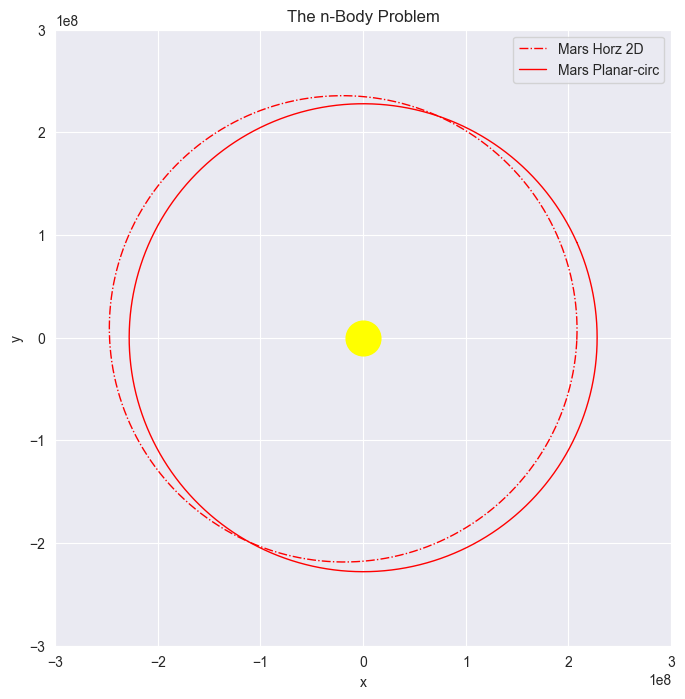

In [46]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
# earth_hor_plt, = ax.plot(earth_2Dx, earth_2Dy, earth_2Dy,'g-.', label='Earth Horz 2D', linewidth=1)
mars_hor_plt, = ax.plot(mars_2Dx, mars_2Dy  ,'r-.', label='Mars Horz 2D', linewidth=1)
# venus_hor_plt, = ax.plot(venus_2Dx, venus_2Dy, venus_2Dz,  'b-.', label='Venus Horz 2D', linewidth=1)

# planet1_plt, = ax.plot(rx_earth, ry_earth, 0, 'green', label='Mars Planar-circ', linewidth=1)
planet2_plt, = ax.plot(rx_mars, ry_mars ,'red', label='Mars Planar-circ', linewidth=1)
# planet3_plt, = ax.plot(rx_venus, ry_venus, 0, 'blue',label='Venus Planar-circ', linewidth=1)

# planet1_dot, = ax.plot([mars_2Dx[0]], [mars_2Dy[0]] ,'o', color='green', markersize=7)
# planet2_dot, = ax.plot([rx_mars[0]], [ry_mars[0]], 'o', color='red', markersize=7)
planet3_dot, = ax.plot(0, 0,  'o', color='yellow', markersize=25)

ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-3e8,3e8)
ax.set_ylabel("y")
ax.set_ylim(-3e8,3e8)


# ax.view_init(90,-90)
plt.grid(True)
plt.legend()
plt.show()

5935680


## VENUS


In [57]:
def find_venus_diff(dt):
    time_s, time_e = 0, (60*60*24*225)
    ts = int(time_e/(dt))
    print(ts)
    t_points = np.linspace(time_s, time_e, ts)

    FRAME = "ECLIPJ2000" # LOAD IN EPHEMERIS DATA
    OBSERVER = "SUN"
    venus = spice.spkezr("VENUS",t_points,FRAME,"NONE", OBSERVER)[0]
    venus_pos = venus[:,:3]

    venus_2D = []
    for i in range(len(venus_pos)):
        venus_2D.append(map_to_2D(venus_pos[i])) 
        # print(earth_pos[i,:])

    venus_2D = np.array(venus_2D)
    peak_dev = 0
    for i in range(len(venus_pos)):
        dev = abs(np.linalg.norm(venus_2D[i]) - D_venus)
        if dev > peak_dev:
            peak_dev = dev
        # print(dev)
    print(peak_dev)
    return peak_dev

max_venus_diff = find_venus_diff(60*30)

10800
790040.9088042825


In [59]:
(max_venus_diff/D_venus)*100

np.float64(0.7305047700455687)

### plotting Venus

In [ ]:
dt = 60*30
time_s, time_e = 0, (60*60*24*687)
ts = int(time_e/(dt))
print(ts)
t_points = np.linspace(time_s, time_e, ts)


In [49]:
venus = spice.spkezr("VENUS",t_points,FRAME,"NONE", OBSERVER)[0]
venusx = venus[:,0]
venusy = venus[:,1]
venusz = venus[:,2]
venusvx = venus[:,3]
venusvy = venus[:,4]
venusvz = venus[:,5]

In [53]:
venus_pos = venus[:,:3]
venus_2D = []
for i in range(len(venus_pos)):
    venus_2D.append(map_to_2D(venus_pos[i])) 
    # print(earth_pos[i,:])
venus_2D = np.array(venus_2D)
venus_2Dx = venus_2D[:,0]
venus_2Dy = venus_2D[:,1]
venus_2Dz = venus_2D[:,2]

In [51]:
init_phase_venus = np.arccos(venus_2D[0,0]/D_venus) 

r_venus = []


for t in t_points:
    rx_venus = D_venus*np.cos(w_venus*t + init_phase_venus)
    ry_venus = D_venus*np.sin(w_venus*t + init_phase_venus)
    r_venus.append([rx_venus, ry_venus, 0])

r_venus = np.array(r_venus)
rx_venus = r_venus[:,0]
ry_venus = r_venus[:,1]

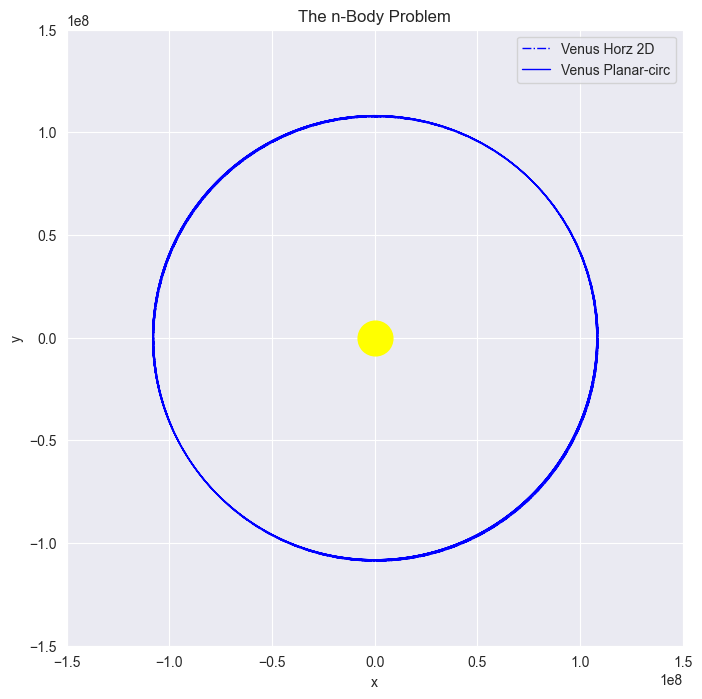

In [56]:
# -------  Plotting the solutions ------- #

fig, ax = plt.subplots(figsize = (13,8))
ax.set_aspect(1)
# earth_hor_plt, = ax.plot(earth_2Dx, earth_2Dy, earth_2Dy,'g-.', label='Earth Horz 2D', linewidth=1)
# mars_hor_plt, = ax.plot(mars_2Dx, mars_2Dy  ,'r-.', label='Mars Horz 2D', linewidth=1)
venus_hor_plt, = ax.plot(venus_2Dx, venus_2Dy,  'b-.', label='Venus Horz 2D', linewidth=1)

# planet1_plt, = ax.plot(rx_earth, ry_earth, 0, 'green', label='Mars Planar-circ', linewidth=1)
# planet2_plt, = ax.plot(rx_mars, ry_mars ,'red', label='Mars Planar-circ', linewidth=1)
planet3_plt, = ax.plot(rx_venus, ry_venus, 'blue',label='Venus Planar-circ', linewidth=1)

# planet1_dot, = ax.plot([mars_2Dx[0]], [mars_2Dy[0]] ,'o', color='green', markersize=7)
# planet2_dot, = ax.plot([rx_mars[0]], [ry_mars[0]], 'o', color='red', markersize=7)
planet3_dot, = ax.plot(0, 0,  'o', color='yellow', markersize=25)

ax.set_title("The n-Body Problem")
ax.set_xlabel("x")
ax.set_xlim(-1.5e8,1.5e8)
ax.set_ylabel("y")
ax.set_ylim(-1.5e8,1.5e8)


# ax.view_init(90,-90)
plt.grid(True)
plt.legend()
plt.show()